<a href="https://colab.research.google.com/github/Edenshmuel/CrimeData/blob/main/Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Edenshmuel/CrimeData.git

import os
import zipfile
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

Cloning into 'CrimeData'...
remote: Enumerating objects: 1091, done.
remote: Counting objects: 100% (338/338), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 1091 (delta 266), reused 179 (delta 177), pack-reused 753 (from 3)
Receiving objects: 100% (1091/1091), 384.19 MiB | 26.05 MiB/s, done.
Resolving deltas: 100% (569/569), done.


In [2]:
zip_folder = 'CrimeData'

relevant_zip_files = [
    f for f in os.listdir(zip_folder)
    if f.startswith('crimes') and f.endswith('.zip')
    and any(year in f for year in ['2019', '2020', '2021', '2022', '2023', '2024', '2025'])
]

combined_data = []

for zip_file in relevant_zip_files:
    zip_path = os.path.join(zip_folder, zip_file)
    extract_path = os.path.join(zip_folder, zip_file.replace('.zip', ''))

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        print(f"Extracted: {zip_file} -> {extract_path}")

    csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]

    for csv_file in csv_files:
        csv_path = os.path.join(extract_path, csv_file)
        df = pd.read_csv(csv_path)
        combined_data.append(df)

combined_data = pd.concat(combined_data, ignore_index=True)

Extracted: crimes2019.zip -> CrimeData/crimes2019
Extracted: crimes2021.zip -> CrimeData/crimes2021
Extracted: crimes2024.zip -> CrimeData/crimes2024
Extracted: crimes2023.zip -> CrimeData/crimes2023
Extracted: crimes2020.zip -> CrimeData/crimes2020
Extracted: crimes2025.zip -> CrimeData/crimes2025
Extracted: crimes2022.zip -> CrimeData/crimes2022


In [3]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748668 entries, 0 to 2748667
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   FictiveIDNumber    object 
 1   Year               int64  
 2   Quarter            object 
 3   YeshuvKod          float64
 4   Yeshuv             object 
 5   PoliceDistrictKod  float64
 6   PoliceDistrict     object 
 7   PoliceMerhavKod    float64
 8   PoliceMerhav       object 
 9   PoliceStationKod   float64
 10  PoliceStation      object 
 11  municipalKod       float64
 12  municipalName      object 
 13  StatisticAreaKod   float64
 14  StatisticArea      object 
 15  StatisticGroupKod  int64  
 16  StatisticGroup     object 
 17  StatisticTypeKod   int64  
 18  StatisticType      object 
dtypes: float64(6), int64(3), object(10)
memory usage: 398.4+ MB


Given the large size of our dataset, optimizing data types is crucial for improving performance and reducing memory usage. Specifically, we will convert float64 and object columns to more efficient data types, which will save space and allow the code to execute faster.

In [4]:
combined_data.describe()

,Year,YeshuvKod,PoliceDistrictKod,PoliceMerhavKod,PoliceStationKod,municipalKod,StatisticAreaKod,StatisticGroupKod,StatisticTypeKod
count,2.748668e+06,2.382938e+06,2.745657e+06,2.745657e+06,2.745657e+06,205446.000000,1.731363e+06,2.748668e+06,2.748668e+06
mean,2.021889e+03,4.690978e+03,3.896985e+07,3.148244e+07,3.682992e+07,35.695813,5.310043e+07,5.358838e+02,5.458906e+02
std,1.938883e+00,2.940571e+03,2.204250e+07,1.536353e+07,2.156501e+07,25.305469,2.740448e+07,8.821360e+02,8.843309e+02
min,2.019000e+03,2.600000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,3.100010e+05,-1.000000e+00,-1.000000e+00
25%,2.020000e+03,2.600000e+03,2.000000e+07,1.500522e+07,1.500571e+07,15.000000,3.000093e+07,2.000000e+02,2.120000e+02
50%,2.022000e+03,5.000000e+03,3.000000e+07,3.120000e+07,3.131200e+07,30.000000,5.000094e+07,4.000000e+02,4.040000e+02
75%,2.024000e+03,7.400000e+03,5.000000e+07,4.110000e+07,5.121000e+07,53.000000,7.700002e+07,7.000000e+02,7.150000e+02
max,2.025000e+03,9.800000e+03,8.000000e+07,7.150000e+07,8.170000e+07,100.000000,9.800000e+07,1.000000e+04,1.003900e+04


In [5]:
missing_values = combined_data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 FictiveIDNumber            0
Year                       0
Quarter                    0
YeshuvKod             365730
Yeshuv                365730
PoliceDistrictKod       3011
PoliceDistrict          3011
PoliceMerhavKod         3011
PoliceMerhav            3011
PoliceStationKod        3011
PoliceStation           3011
municipalKod         2543222
municipalName        2360322
StatisticAreaKod     1017305
StatisticArea        1105058
StatisticGroupKod          0
StatisticGroup             0
StatisticTypeKod           0
StatisticType              0
dtype: int64


<Figure size 1000x600 with 0 Axes>

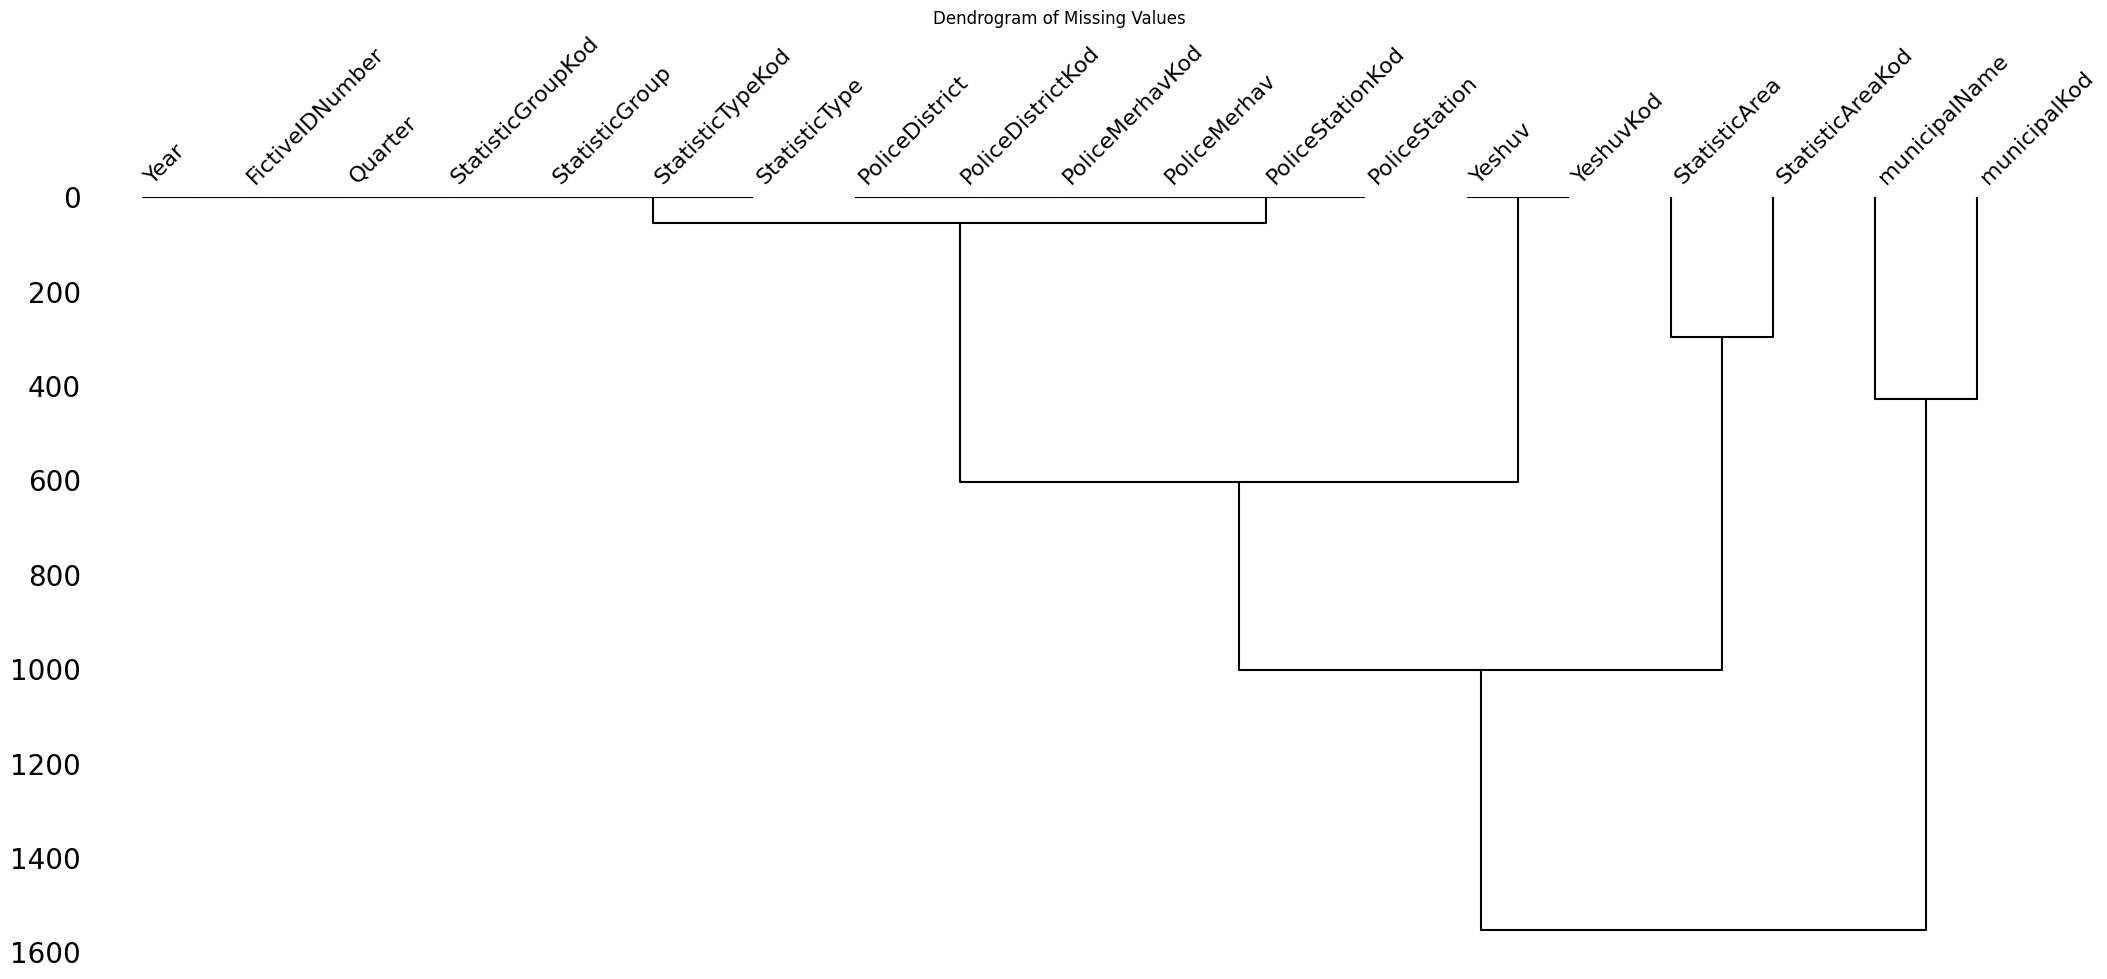

In [6]:
# Adjusting the size of the dendrogram for a smaller display
plt.figure(figsize=(10, 6))  # Reduced width and height
msno.dendrogram(combined_data)
plt.title('Dendrogram of Missing Values')
plt.show()

The dendrogram visualizes the distance or dissimilarity between the missing data patterns across columns. For example:

*   municipalName and municipalKod are clustered together, indicating similar missing data patterns.
*   StatisticType, StatisticTypeKod, Yeshuv, and YeshuvKod also form a group, suggesting similar patterns of missingness. This visualization is helpful for identifying relationships in missing data and deciding on appropriate strategies for handling it.




After exploring the structure and missing data in our dataset, we now turn to examine the geographical distribution of the data.

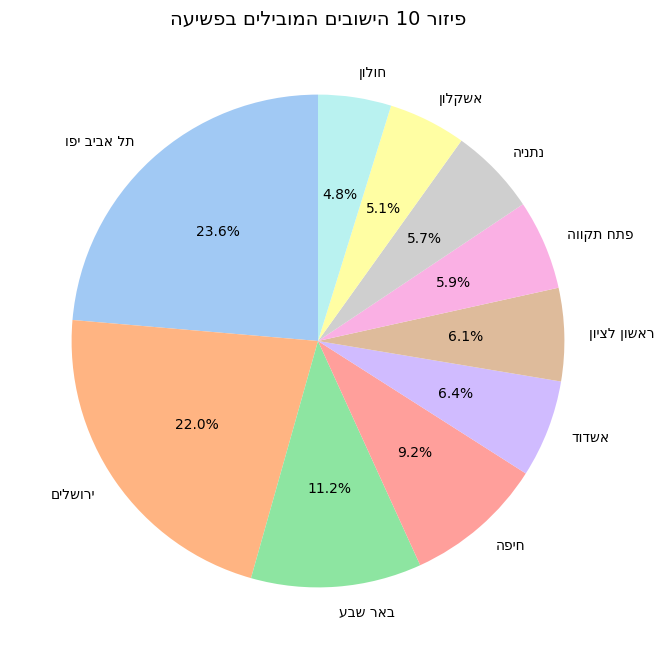

In [7]:
# Reverse Hebrew text for the pie chart labels
def reverse_hebrew_text(text):
    return text[::-1] if isinstance(text, str) else text

# Reverse the labels in the 'Yeshuv' column so it fits the Hebrew RTL
if 'Yeshuv' in combined_data.columns:
    combined_data['Yeshuv'] = combined_data['Yeshuv'].apply(reverse_hebrew_text)

    # Calculate the top 10 Yeshuv by count
    top_yeshuv = combined_data['Yeshuv'].value_counts().head(10)

    # Create a pie chart for the top 10 Yeshuv
    plt.figure(figsize=(8, 8))
    top_yeshuv.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.title(reverse_hebrew_text('פיזור 01 הישובים המובילים בפשיעה'), fontsize=14)
    plt.ylabel('')
    plt.show()
else:
    print("The 'Yeshuv' column does not exist in the dataset.")


The geographical analysis shows that Tel Aviv (תל אביב יפו) and Jerusalem (ירושלים) account for the largest shares in the dataset. Other notable settlements, such as Ashdod (אשדוד), Be'er Sheva (באר שבע), and Holon (חולון), also make significant contributions, though to a lesser extent.

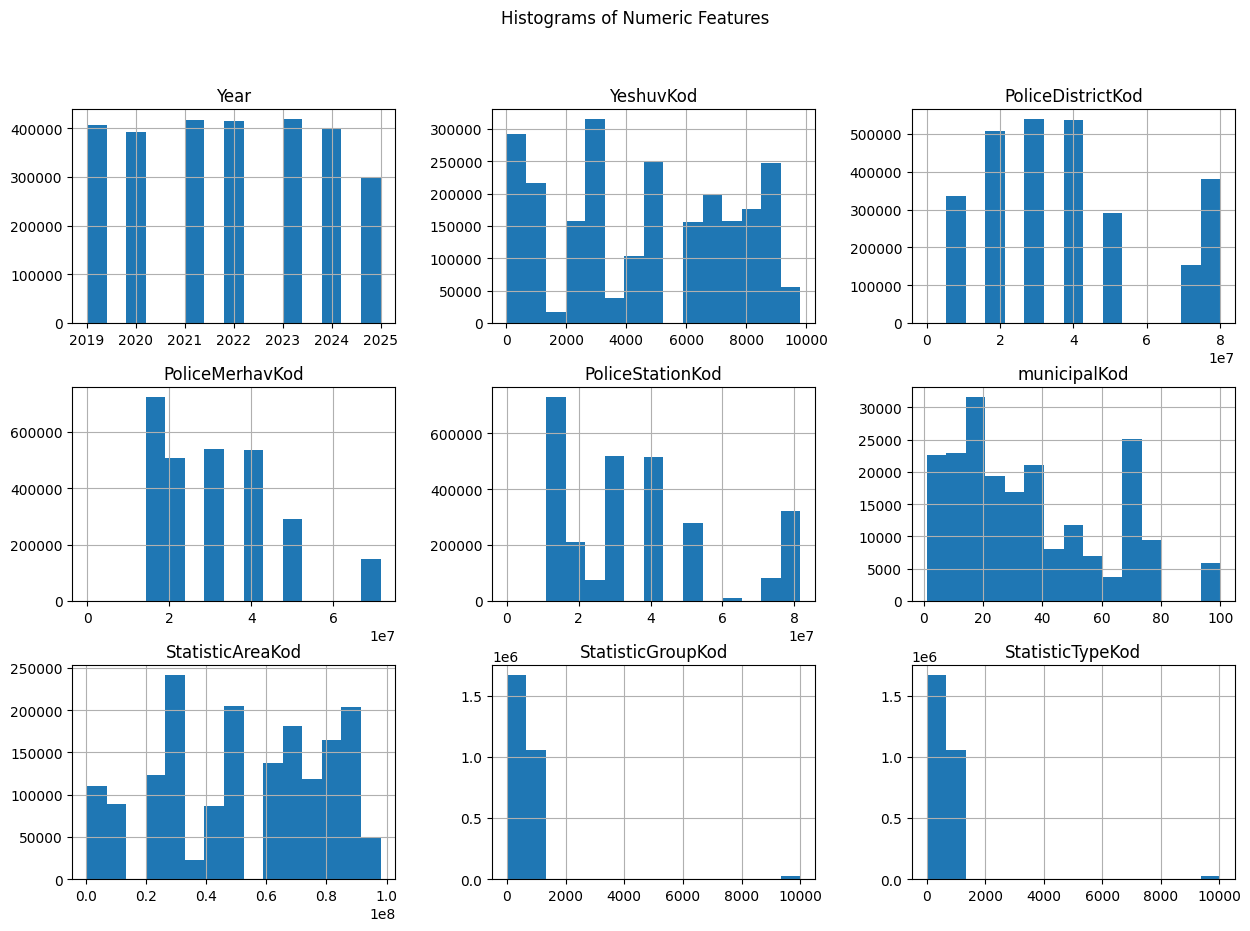

In [8]:
numeric_features = combined_data.select_dtypes(include=['int64', 'float64']).columns

combined_data[numeric_features].hist(bins=15, figsize=(15, 10))
plt.suptitle("Histograms of Numeric Features")
plt.show()

The yearly distribution is relatively balanced across 2019–2024. The lower number of records observed for 2025 is expected, as the dataset currently includes data only for the first three quarters (Q1–Q3) of that year.

In [9]:
quarters_by_year = (
    combined_data
    .dropna(subset=['Year', 'Quarter'])
    .groupby('Year')['Quarter']
    .unique()
)

for year, quarters in quarters_by_year.items():
    print(int(year), sorted(quarters))

2019 ['Q1', 'Q2', 'Q3', 'Q4']
2020 ['Q1', 'Q2', 'Q3', 'Q4']
2021 ['Q1', 'Q2', 'Q3', 'Q4']
2022 ['Q1', 'Q2', 'Q3', 'Q4']
2023 ['Q1', 'Q2', 'Q3', 'Q4']
2024 ['Q1', 'Q2', 'Q3', 'Q4']
2025 ['Q1', 'Q2', 'Q3']


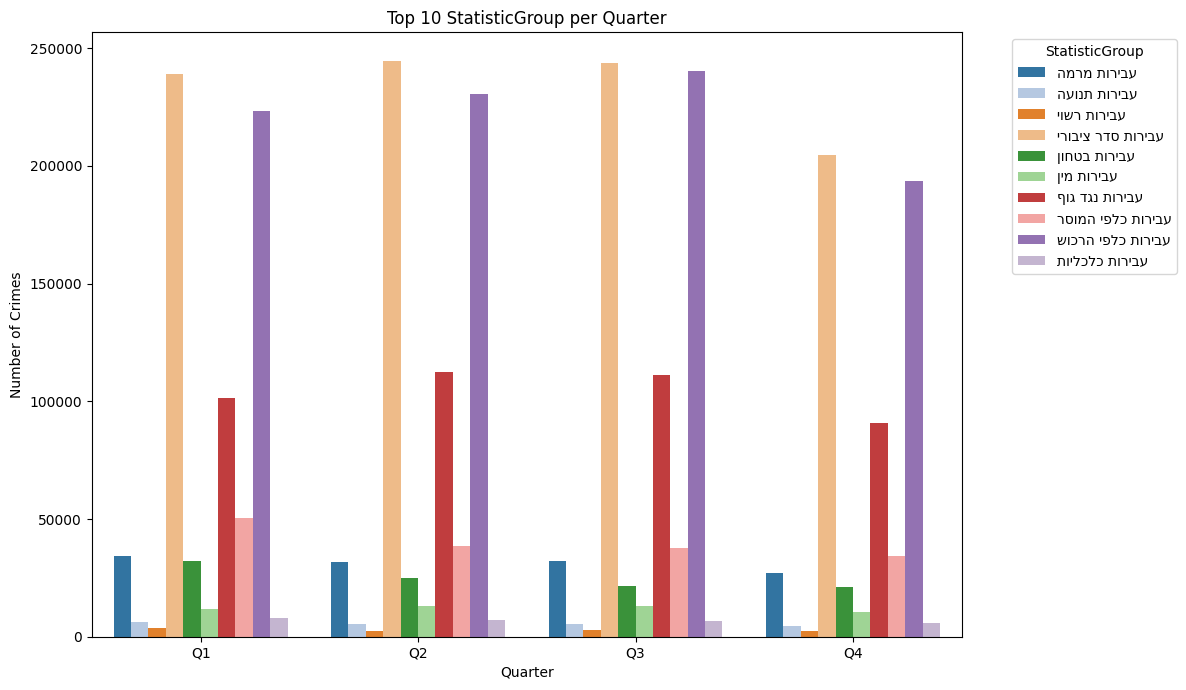

In [10]:
!apt-get install -y fonts-freefont-ttf > /dev/null 2>&1  # Suppress warnings and messages

# Reverse Hebrew text for the 'StatisticType' column
def reverse_hebrew_text(text):
    return text[::-1] if isinstance(text, str) else text  # Reverse strings only

# Find the top N StatisticType categories by count
top_N = 10  # Adjust N as needed
top_types = combined_data['StatisticGroup'].value_counts().head(top_N).index

# Filter the DataFrame to include only these top categories
filtered_df = combined_data[combined_data['StatisticGroup'].isin(top_types)].copy()

# Apply the reverse function only to the 'StatisticType' column
filtered_df['StatisticGroup'] = filtered_df['StatisticGroup'].apply(reverse_hebrew_text)

# Group data by quarter and StatisticType
crime_grouped = filtered_df.groupby(['Quarter', 'StatisticGroup']).size().reset_index(name='count')

# Plot the data
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

plt.figure(figsize=(12, 7))
sns.barplot(data=crime_grouped, x='Quarter', y='count', hue='StatisticGroup', palette='tab20')

# Add labels and titles
plt.xlabel('Quarter')
plt.ylabel('Number of Crimes')
plt.title(f'Top {top_N} StatisticGroup per Quarter')
plt.legend(title='StatisticGroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.close()


The analysis of the top 10 StatisticGroup categories per quarter highlights some key trends. Two categories, עבירות סדר ציבורי (Public Order Offenses) and עבירות כלכליות (Economic Offenses), dominate the dataset, consistently reporting the highest number of crimes across all four quarters. In contrast, categories like עבירות נגד גוף (Offenses Against the Body) and עבירות מין (Sexual Offenses) contribute significantly fewer crimes.

Overall, the number of crimes for most categories remains stable across quarters, indicating no significant seasonal variation in crime numbers.

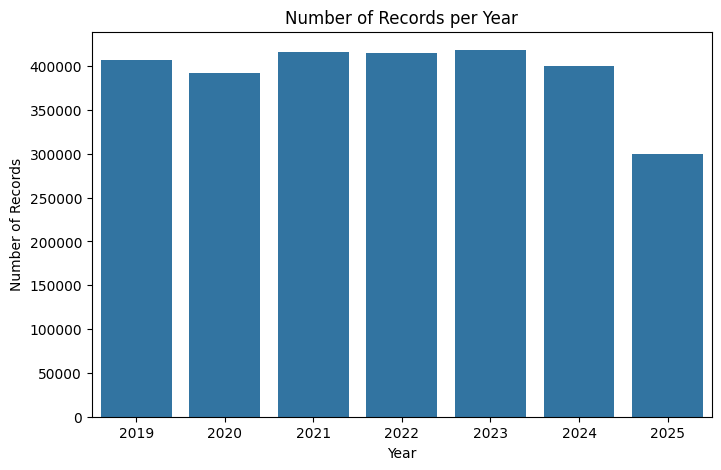

In [11]:
year_counts = combined_data['Year'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title('Number of Records per Year')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.show()

The number of records per year remains relatively stable from 2019 to 2024. A noticeable decrease is observed for 2025, which is expected since the dataset currently contains data only for the first three quarters (Q1–Q3) of that year, as confirmed by the quarter-level analysis.

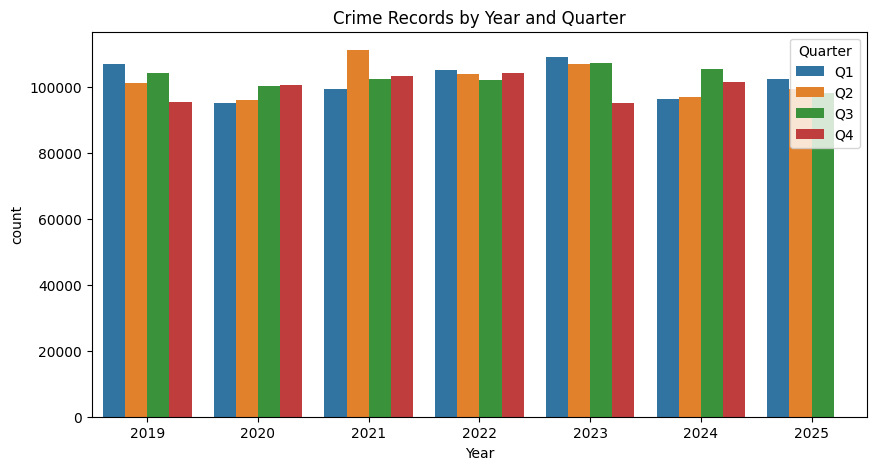

In [12]:
quarter_counts = (
    combined_data.groupby(['Year','Quarter'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(10,5))
sns.barplot(data=quarter_counts, x='Year', y='count', hue='Quarter')
plt.title('Crime Records by Year and Quarter')
plt.show()

Crime records are relatively evenly distributed across quarters within each year. The years 2019–2024 include data for all four quarters, while 2025 currently contains records only for Q1–Q3, resulting in a lower total count for that year.

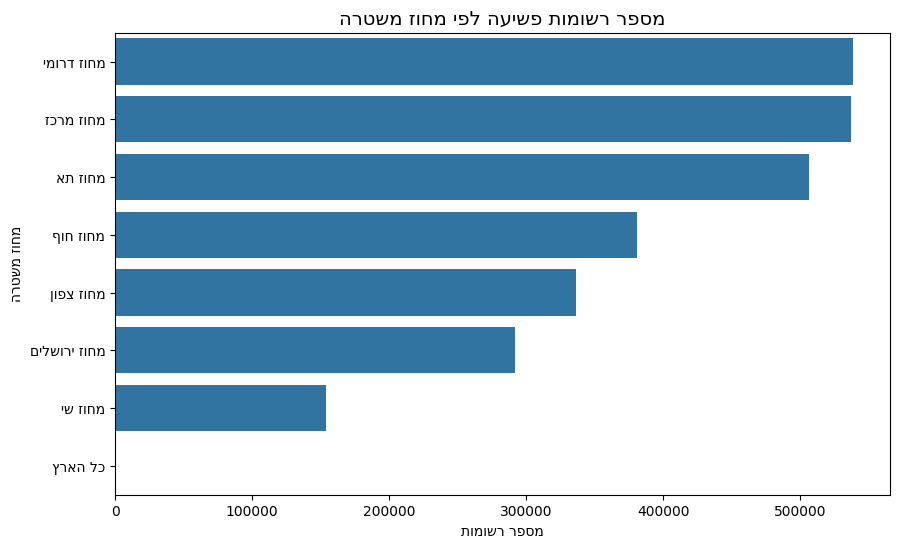

In [17]:
district_counts = combined_data['PoliceDistrict'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=district_counts.values,
    y=[reverse_hebrew_text(str(x)) for x in district_counts.index]
)

plt.title(reverse_hebrew_text('מספר רשומות פשיעה לפי מחוז משטרה'), fontsize=14)
plt.xlabel(reverse_hebrew_text('מספר רשומות'))
plt.ylabel(reverse_hebrew_text('מחוז משטרה'))
plt.show()

The distribution of crime records across police districts is not uniform. The Southern and Central districts contain the highest number of records, followed by the Tel Aviv district. In contrast, the Jerusalem and Judea and Samaria (Shai) districts show considerably lower counts. This pattern may reflect differences in population size, urban density, or reporting activity across districts.

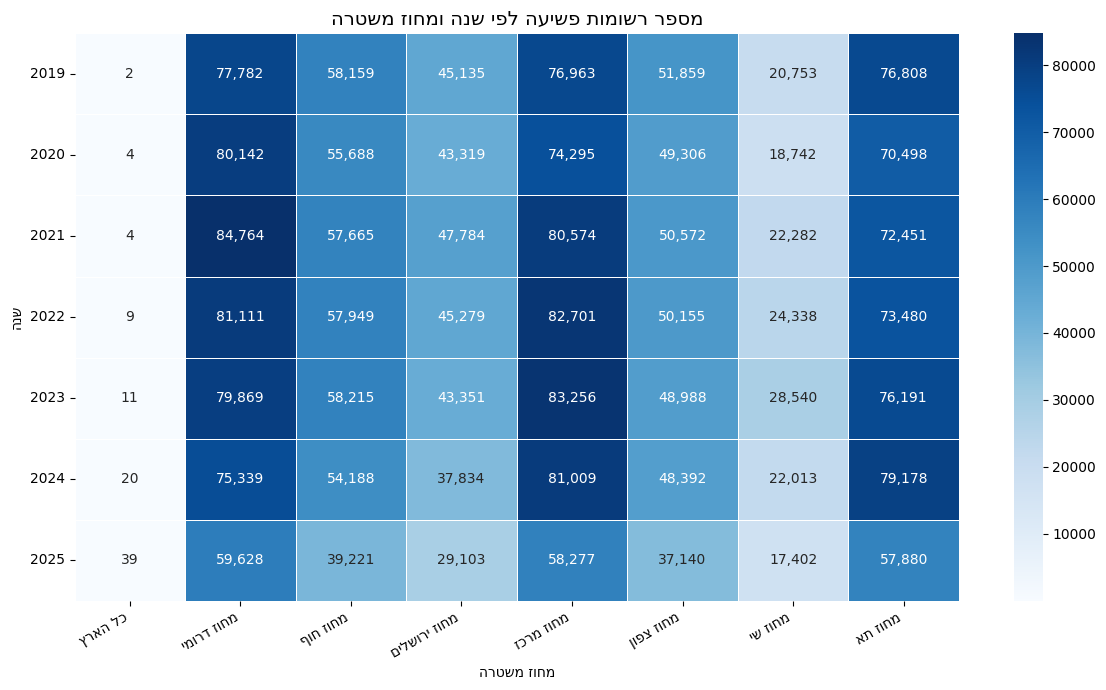

In [18]:
heatmap_data = (
    combined_data
    .groupby(['Year', 'PoliceDistrict'])
    .size()
    .unstack(fill_value=0)
)

heatmap_data = heatmap_data.rename(columns=lambda x: reverse_hebrew_text(str(x)))

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_data,
    cmap='Blues',
    annot=True,
    fmt=',.0f',
    linewidths=0.5
)

plt.title(reverse_hebrew_text('מספר רשומות פשיעה לפי שנה ומחוז משטרה'), fontsize=14)
plt.xlabel(reverse_hebrew_text('מחוז משטרה'))
plt.ylabel(reverse_hebrew_text('שנה'))
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The heatmap illustrates the distribution of crime records across police districts over time. The Central, Southern, and Tel Aviv districts consistently exhibit the highest number of records across most years, while the Jerusalem and Judea and Samaria (Shai) districts show comparatively lower counts. The overall distribution remains relatively stable between 2019 and 2024. The lower values observed in 2025 are expected, as the dataset currently includes records only for the first three quarters of that year.

# **Supervised Models Conclusion**

In [ ]:
# Define the metrics for each model
metrics = {
    "Baseline Model": {
        "Accuracy": 0.001,
        "Precision": 0.000001,
        "Recall": 0.001,
        "F1 Score": 0.000002
    },
    "Decision Tree": {
        "Accuracy": 0.043,
        "Precision": 0.279,
        "Recall": 0.043,
        "F1 Score": 0.048
    },
    "DNN": {
        "Accuracy": 0.356,
        "Precision": 0.239,
        "Recall": 0.356,
        "F1 Score": 0.247
    },
    "Random Forest": {
        "Accuracy": 0.048,
        "Precision": 0.300,
        "Recall": 0.048,
        "F1 Score": 0.070
    },
    "LightGBM": {
        "Accuracy": 0.116,
        "Precision": 0.302,
        "Recall": 0.116,
        "F1 Score": 0.137
    },
    "XGBoost": {
        "Accuracy": 0.382,
        "Precision": 0.352,
        "Recall": 0.382,
        "F1 Score": 0.314
    }
}


In [ ]:
# Create a DataFrame from the metrics dictionary
df_metrics = pd.DataFrame(metrics).T

# Sort the DataFrame by the 'Accuracy' column in descending order
df_metrics_sorted = df_metrics.sort_values(by='Accuracy', ascending=False)

# Print the sorted comparison table
print(df_metrics_sorted)

# Optionally, save the sorted comparison table to a CSV file
df_metrics_sorted.to_csv("sorted_model_comparison_table.csv", index=True)

                Accuracy  Precision  Recall  F1 Score
XGBoost            0.382   0.352000   0.382  0.314000
DNN                0.356   0.239000   0.356  0.247000
LightGBM           0.116   0.302000   0.116  0.137000
Random Forest      0.048   0.300000   0.048  0.070000
Decision Tree      0.043   0.279000   0.043  0.048000
Baseline Model     0.001   0.000001   0.001  0.000002


The XGBoost model outperforms all other models in terms of accuracy, precision, recall, and F1 score. It should be the preferred choice for this task.

DNN Performance: The Deep Neural Network also performs well and could be considered as an alternative to XGBoost if further improvements are made.

Tree-Based Models: The Decision Tree and Random Forest models perform poorly, indicating that they might not handle the complexity of the data well.

LightGBM: While better than the Random Forest, LightGBM still lags behind the XGBoost and DNN models.